# Module 3 — Alpha Strategy

Signal generation and validation:  
**Kalman Pairs Trading**, **Cross-Sectional Momentum**, **backtest with transaction costs**, **walk-forward validation**.

In [1]:
%matplotlib inline
import sys
from pathlib import Path
sys.path.insert(0, str(Path("../src").resolve()))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from signals import KalmanPairsSignal, CrossSectionalMomentum, synthetic_pair, synthetic_universe
from backtest import Backtest, compare_strategies
from validation import WalkForwardAnalysis

np.random.seed(42)
print("OK")

OK


## 1. Synthetic data

In [2]:
# Cointegrated price pair for Kalman signal
prices_y, prices_x = synthetic_pair(n_days=1000, seed=42)

# Equity universe for cross-sectional momentum
universe_rets = synthetic_universe(n_assets=10, n_days=1000, seed=7)

print(f"Pair     : {prices_y.name} / {prices_x.name}  |  {len(prices_y)} days")
print(f"Universe : {universe_rets.shape[1]} assets  |  {len(universe_rets)} days")

Pair     : ASSET_A / ASSET_B  |  1000 days
Universe : 10 assets  |  1000 days


## 2. Kalman Pairs Trading Signal

**Key points:**
- Entry threshold parameter is `enter_z` (not `entry_z`)
- `.fit()` takes `pd.Series` price objects — **not** numpy arrays
- After fitting: `betas_`, `spreads_`, `zscore_`, `signal_` are populated
- Use `.pnl_series(y, x)` to compute daily P&L for the backtest

In [3]:
# enter_z (not entry_z) — fit takes pd.Series, not .values
kf = KalmanPairsSignal(delta=1e-5, Ve=1e-3, enter_z=2.0, exit_z=0.5)
kf.fit(prices_y, prices_x)

print(f"Mean hedge ratio   : {kf.betas_.mean():.4f}")
print(f"Z-score range      : [{kf.zscore_.min():.2f}, {kf.zscore_.max():.2f}]")
print(f"Long  signals      : {(kf.signal_ == 1).sum()}")
print(f"Short signals      : {(kf.signal_ == -1).sum()}")
print(f"Flat  (no pos.)    : {(kf.signal_ == 0).sum()}")

Mean hedge ratio   : 0.7982
Z-score range      : [-3.10, 3.37]
Long  signals      : 56
Short signals      : 58
Flat  (no pos.)    : 886


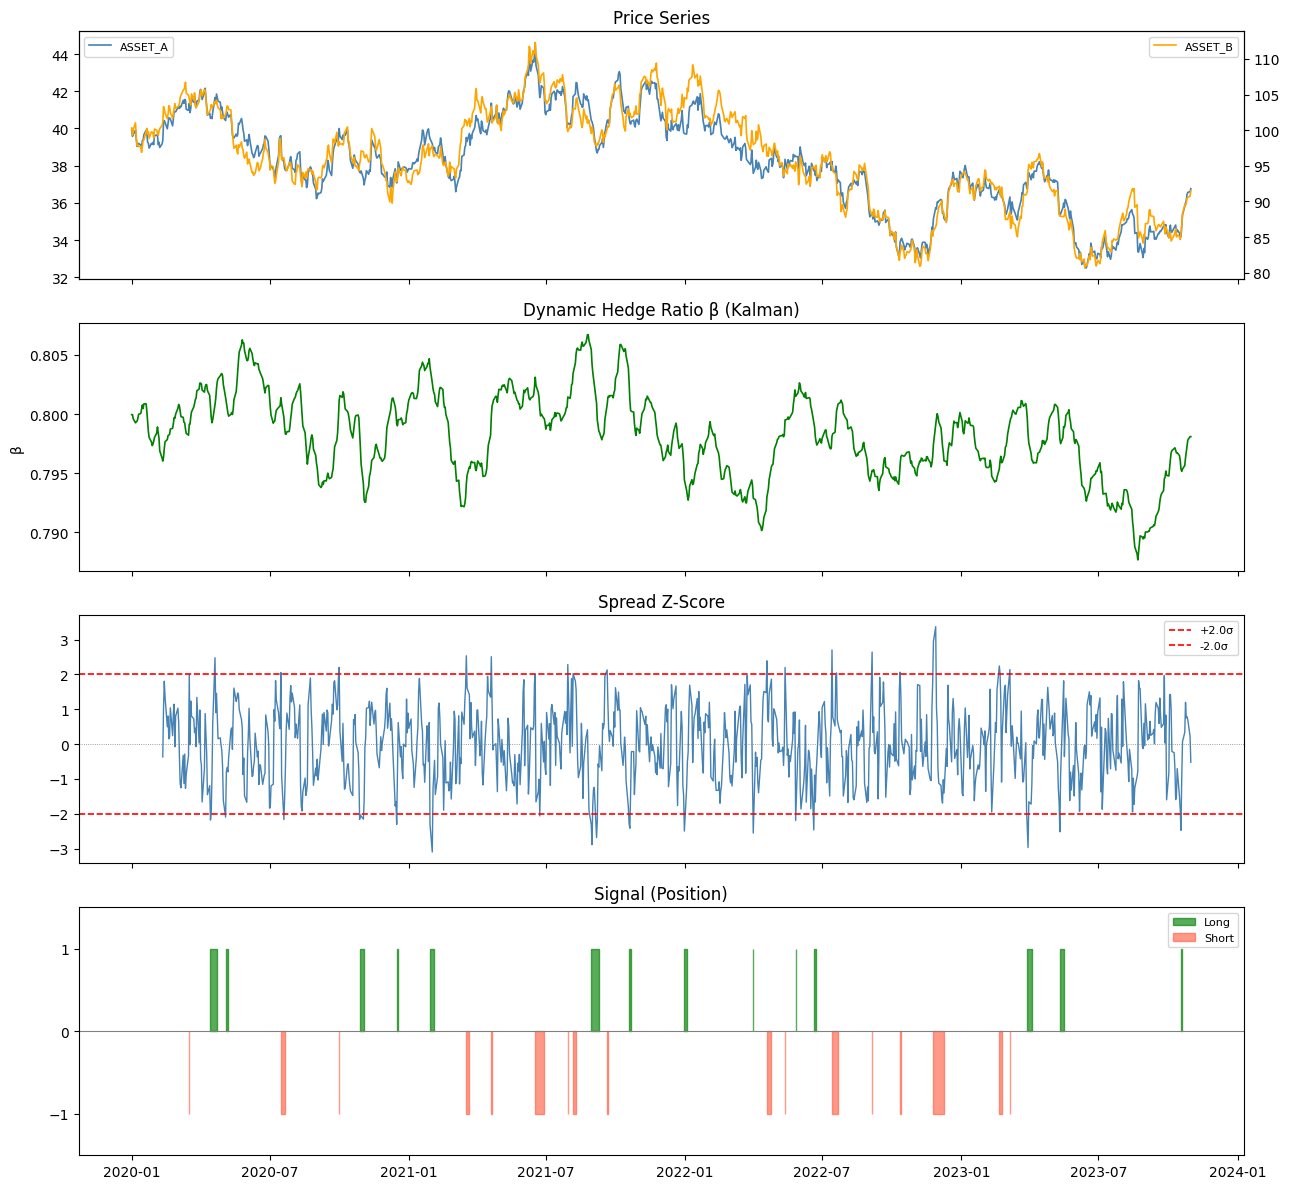

In [4]:
fig, axes = plt.subplots(4, 1, figsize=(13, 12), sharex=True)

# Prices
ax1b = axes[0].twinx()
axes[0].plot(prices_y.index, prices_y.values, color="steelblue", lw=1.2, label=prices_y.name)
ax1b.plot(prices_x.index, prices_x.values, color="orange", lw=1.2, label=prices_x.name)
axes[0].set_title("Price Series")
axes[0].legend(loc="upper left", fontsize=8); ax1b.legend(loc="upper right", fontsize=8)

# Hedge ratio
axes[1].plot(kf.betas_.index, kf.betas_.values, color="green", lw=1.2)
axes[1].set_title("Dynamic Hedge Ratio \u03b2 (Kalman)"); axes[1].set_ylabel("\u03b2")

# Z-score
axes[2].plot(kf.zscore_.index, kf.zscore_.values, color="steelblue", lw=1.0)
axes[2].axhline( kf.enter_z, color="red", lw=1.2, ls="--", label=f"+{kf.enter_z}\u03c3")
axes[2].axhline(-kf.enter_z, color="red", lw=1.2, ls="--", label=f"-{kf.enter_z}\u03c3")
axes[2].axhline(0, color="gray", lw=0.6, ls=":")
axes[2].set_title("Spread Z-Score"); axes[2].legend(fontsize=8)

# Signal
sig = kf.signal_
axes[3].fill_between(sig.index, sig.values, where=sig.values > 0,
                     color="green", alpha=0.65, step="post", label="Long")
axes[3].fill_between(sig.index, sig.values, where=sig.values < 0,
                     color="tomato", alpha=0.65, step="post", label="Short")
axes[3].axhline(0, color="gray", lw=0.8)
axes[3].set_title("Signal (Position)")
axes[3].set_yticks([-1, 0, 1]); axes[3].set_ylim(-1.5, 1.5); axes[3].legend(fontsize=8)

plt.tight_layout(); plt.show()

## 3. Backtest — Kalman Pairs

`Backtest` takes a **P&L series** (not a signal object).  
Call `signal.pnl_series(y, x)` first.  
`.run()` returns a `PerformanceMetrics` dataclass.

In [5]:
pnl_kalman = kf.pnl_series(prices_y, prices_x)

bt_kalman = Backtest(
    pnl_series=pnl_kalman,
    signal_series=kf.signal_,
    transaction_cost=0.001,
    name="Kalman Pairs",
)
m_kalman = bt_kalman.run()   # returns PerformanceMetrics
print(m_kalman)


----------------------------------------------------
  Kalman Pairs
----------------------------------------------------
  Observations             1000
  Trades (non-zero)         145
----------------------------------------------------
  Total Return             4.36 %
  Annual Return            1.12 %
  Annual Vol               3.10 %
----------------------------------------------------
  Sharpe Ratio            0.363
  Sortino Ratio           0.154
  Calmar Ratio            0.250
  Max Drawdown             4.49 %
----------------------------------------------------
  Hit Rate                44.83 %
  Profit Factor           1.174
  Avg Win                0.4630 %
  Avg Loss              -0.3204 %
----------------------------------------------------


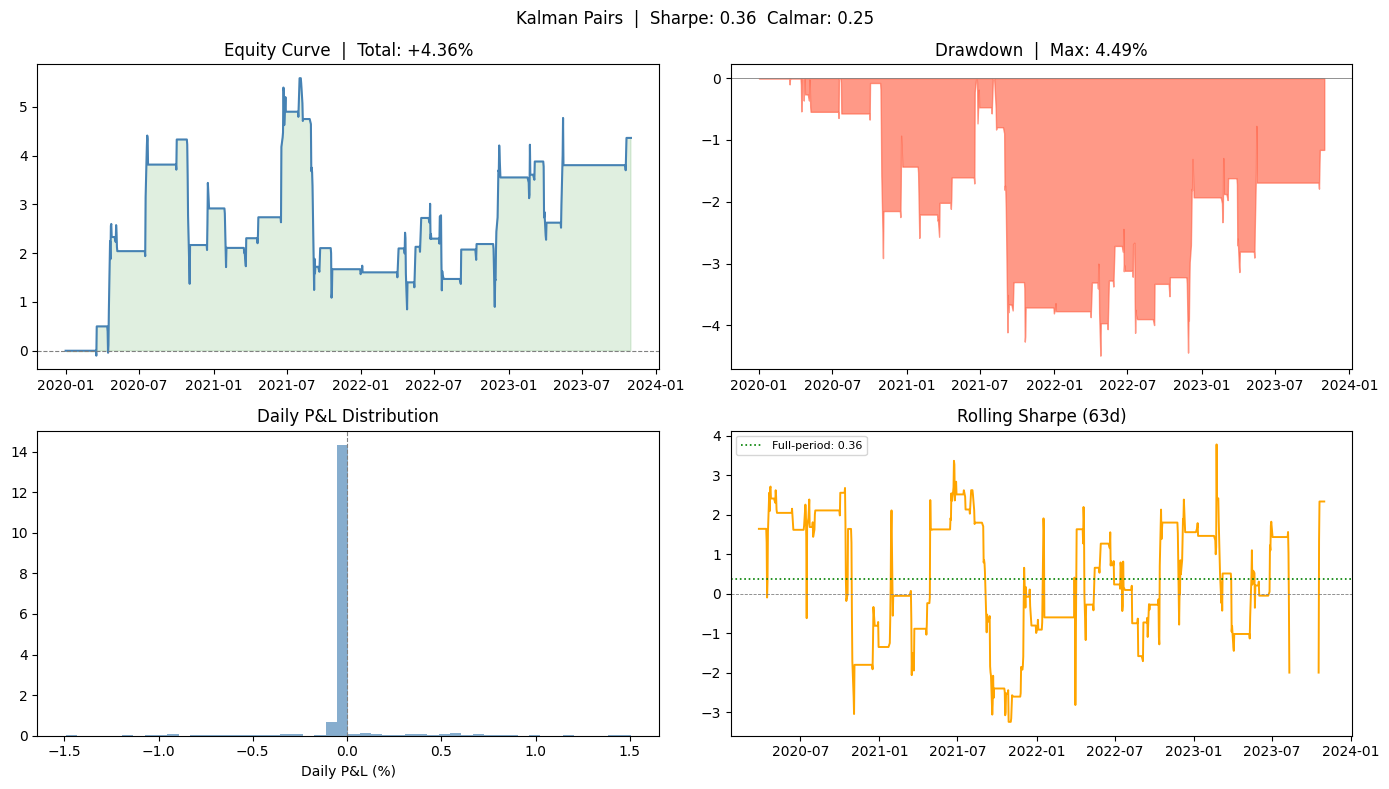

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

eq = m_kalman.equity_curve * 100
axes[0, 0].plot(eq.index, eq.values, color="steelblue", lw=1.5)
axes[0, 0].fill_between(eq.index, eq.values, where=eq.values >= 0, alpha=0.12, color="green")
axes[0, 0].fill_between(eq.index, eq.values, where=eq.values <  0, alpha=0.20, color="tomato")
axes[0, 0].axhline(0, color="gray", lw=0.8, ls="--")
axes[0, 0].set_title(f"Equity Curve  |  Total: {m_kalman.total_return*100:+.2f}%")

dd = m_kalman.drawdown_series * 100
axes[0, 1].fill_between(dd.index, dd.values, alpha=0.65, color="tomato")
axes[0, 1].axhline(0, color="gray", lw=0.6)
axes[0, 1].set_title(f"Drawdown  |  Max: {m_kalman.max_drawdown*100:.2f}%")

pnl = m_kalman.daily_pnl * 100
axes[1, 0].hist(pnl, bins=50, density=True, color="steelblue", alpha=0.65, edgecolor="none")
axes[1, 0].axvline(0, color="gray", lw=0.8, ls="--")
axes[1, 0].set_title("Daily P&L Distribution"); axes[1, 0].set_xlabel("Daily P&L (%)")

window = min(63, len(pnl) // 4)
roll = pnl.rolling(window)
rs = roll.mean() / roll.std(ddof=1) * np.sqrt(252)
axes[1, 1].plot(rs.index, rs.values, color="orange", lw=1.4)
axes[1, 1].axhline(0, color="gray", lw=0.6, ls="--")
axes[1, 1].axhline(m_kalman.sharpe_ratio, color="green", lw=1.2, ls=":",
                   label=f"Full-period: {m_kalman.sharpe_ratio:.2f}")
axes[1, 1].set_title(f"Rolling Sharpe ({window}d)"); axes[1, 1].legend(fontsize=8)

plt.suptitle(f"Kalman Pairs  |  Sharpe: {m_kalman.sharpe_ratio:.2f}  Calmar: {m_kalman.calmar_ratio:.2f}",
             fontsize=12)
plt.tight_layout(); plt.show()

## 4. Cross-Sectional Momentum

Parameter is `quantile` (not `top_pct` / `bottom_pct`).

In [7]:
# quantile (not top_pct / bottom_pct)
mom = CrossSectionalMomentum(lookback=60, quantile=0.25)
mom.fit(universe_rets)

pnl_mom = mom.pnl_series(universe_rets)

bt_mom = Backtest(
    pnl_series=pnl_mom,
    transaction_cost=0.001,
    name="Cross-Sectional Momentum",
)
m_mom = bt_mom.run()
print(m_mom)


----------------------------------------------------
  Cross-Sectional Momentum
----------------------------------------------------
  Observations             1000
  Trades (non-zero)         940
----------------------------------------------------
  Total Return            73.19 %
  Annual Return           18.72 %
  Annual Vol              31.22 %
----------------------------------------------------
  Sharpe Ratio            0.600
  Sortino Ratio           0.572
  Calmar Ratio            0.570
  Max Drawdown            32.84 %
----------------------------------------------------
  Hit Rate                52.98 %
  Profit Factor           1.102
  Avg Win                1.6149 %
  Avg Loss              -1.6514 %
----------------------------------------------------


## 5. Strategy comparison

`compare_strategies` takes `list[PerformanceMetrics]` — the objects returned by `.run()`, not `Backtest` objects.

In [8]:
# Pass PerformanceMetrics objects (result of .run()), not Backtest objects
comparison = compare_strategies([m_kalman, m_mom])
print(comparison.to_string())

                          Total Return (%)  Annual Return (%)  Annual Vol (%)  Sharpe  Sortino  Calmar  Max DD (%)  Hit Rate (%)  Profit Factor
Kalman Pairs                          4.36               1.12            3.10   0.363    0.154    0.25        4.49         44.83          1.174
Cross-Sectional Momentum             73.19              18.72           31.22   0.600    0.572    0.57       32.84         52.98          1.102


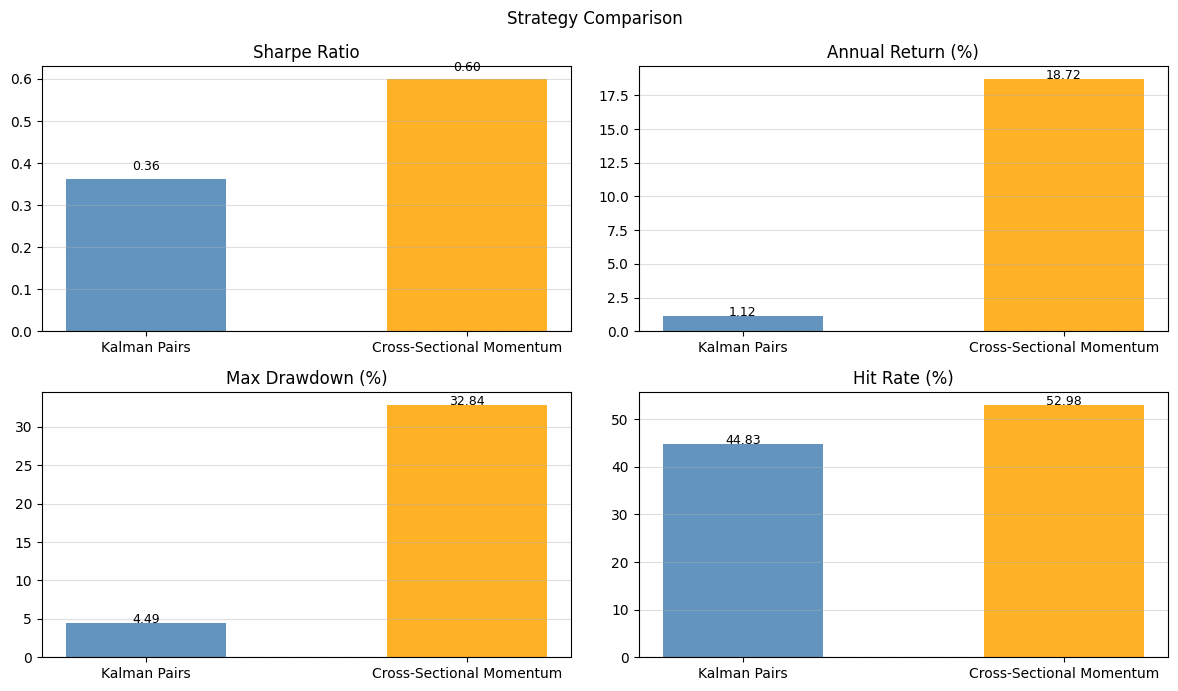

In [9]:
palette = ["steelblue", "orange"]
cols = [("Sharpe", "Sharpe Ratio"), ("Annual Return (%)", "Annual Return (%)"),
        ("Max DD (%)", "Max Drawdown (%)"), ("Hit Rate (%)", "Hit Rate (%)")]

fig, axes = plt.subplots(2, 2, figsize=(12, 7))
for ax, (col, title) in zip(axes.flat, cols):
    vals = comparison[col].values
    bars = ax.bar(comparison.index, vals, color=palette[:len(vals)], alpha=0.85, width=0.5)
    ax.axhline(0, color="gray", lw=0.8, ls="--"); ax.set_title(title)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.02, f"{v:.2f}", ha="center", fontsize=9)
    ax.grid(axis="y", alpha=0.4)

plt.suptitle("Strategy Comparison", fontsize=12)
plt.tight_layout(); plt.show()

## 6. Walk-Forward Validation

`WalkForwardAnalysis.run()` signature: `(prices_y, prices_x, signal_factory, cost)`  
where `signal_factory` is a **callable** `(y_train, x_train) -> fitted KalmanPairsSignal`.

In [10]:
def signal_factory(y_train: pd.Series, x_train: pd.Series) -> KalmanPairsSignal:
    return KalmanPairsSignal(delta=1e-5, Ve=1e-3, enter_z=2.0, exit_z=0.5).fit(y_train, x_train)

# step_size (not step)
wf = WalkForwardAnalysis(train_size=500, test_size=100, step_size=100)
wf_result = wf.run(prices_y, prices_x, signal_factory, cost=0.001)

print(f"OOS Sharpe       : {wf_result.oos_sharpe:.4f}")
print(f"OOS Max Drawdown : {wf_result.oos_max_drawdown*100:.2f}%")
print()
print(wf_result.summary().to_string())

OOS Sharpe       : 0.9551
OOS Max Drawdown : 1.53%

        Sharpe  Annual Ret (%)  Max DD (%)  Hit Rate (%)
Fold 1   0.798            0.81        0.23         42.86
Fold 2  -0.213           -0.78        1.72         39.13
Fold 3   1.236            3.67        1.26         53.33
Fold 4   0.181            0.68        1.87         44.44
Fold 5   1.849            1.36        0.10         66.67


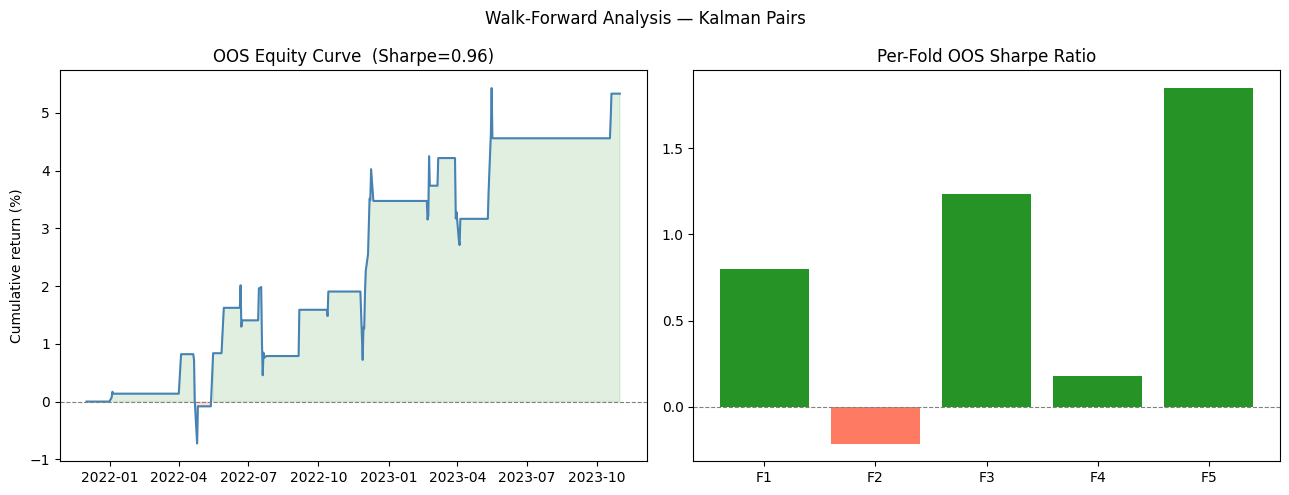

In [11]:
oos = wf_result.oos_pnl
eq  = (np.cumprod(1 + oos.values) - 1) * 100
fold_sharpes = [m.get("Sharpe", 0) for m in wf_result.fold_metrics]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(oos.index, eq, color="steelblue", lw=1.5)
axes[0].fill_between(oos.index, eq, where=np.array(eq) >= 0, alpha=0.12, color="green")
axes[0].fill_between(oos.index, eq, where=np.array(eq) <  0, alpha=0.20, color="tomato")
axes[0].axhline(0, color="gray", lw=0.8, ls="--")
axes[0].set_title(f"OOS Equity Curve  (Sharpe={wf_result.oos_sharpe:.2f})")
axes[0].set_ylabel("Cumulative return (%)")

colors = ["green" if s >= 0 else "tomato" for s in fold_sharpes]
axes[1].bar(range(len(fold_sharpes)), fold_sharpes, color=colors, alpha=0.85)
axes[1].axhline(0, color="gray", lw=0.8, ls="--")
axes[1].set_title("Per-Fold OOS Sharpe Ratio")
axes[1].set_xticks(range(len(fold_sharpes)))
axes[1].set_xticklabels([f"F{i+1}" for i in range(len(fold_sharpes))])

plt.suptitle("Walk-Forward Analysis — Kalman Pairs", fontsize=12)
plt.tight_layout(); plt.show()